# Pharmacy Sales - Baseline Models for Benchmarking

This notebook implements forecasting models that serve as **competitive benchmarks** for more sophisticated models (SARIMA, XGBoost).

**Data Pipeline:**
1. ✅ `data_cleaning.ipynb` - Cleaned data (outliers handled, 100% quality)
2. ✅ `pharmacy_sales_feature_engineering.ipynb` - Created train/test splits
3. 📍 **This notebook** - Baseline/benchmark models

**Models Implemented:**

**Simple Baselines (True Baselines):**
1. **Naive Forecast** - Last observed value
2. **Moving Average (MA)** - Average of last N periods
3. **Seasonal Naive** - Value from same period last year

**Intermediate Models (Competitive Benchmarks):**

4. **Weighted Moving Average (WMA)** - Weighted average favoring recent values

5. **Simple Exponential Smoothing (SES)** - Exponentially weighted average**Note on Terminology:** While all models here are called "baselines" for simplicity, Holt-Winters is technically an **intermediate forecasting model** that serves as a **competitive benchmark**. It's more sophisticated than true baselines (Naive, MA) but simpler than advanced statistical models (SARIMA) or machine learning (XGBoost).

6. **Holt-Winters** - Triple exponential smoothing with trend and seasonality

## Model Complexity Hierarchy

Understanding where these models fit in the forecasting landscape:

```
Simplicity ←------------------------→ Complexity

[Simple Baselines]  [Intermediate]  [Advanced Stats]  [Machine Learning]
     ↓                   ↓                ↓                  ↓
 • Naive            • Holt-Winters    • SARIMA          • XGBoost
 • MA               • SES             • ARIMAX          • Random Forest
 • Seasonal Naive   • WMA             • Prophet         • LSTM/Neural Nets

Minimum Bar         Competitive      Target to Beat    Final Contender
```

**Our Benchmarking Strategy:**
1. **Simple Baselines** establish minimum acceptable performance
2. **Holt-Winters** (intermediate) sets a competitive benchmark
3. **SARIMA** must beat Holt-Winters to justify complexity
4. **XGBoost** must beat both to justify ML approach

**Success Criteria:**
- SARIMA/XGBoost MAE < 6.91 (Holt-Winters performance)
- If they can't beat Holt-Winters, the added complexity isn't justified


## Setup & Imports

In [1]:
# Add project root to path
import sys
import os

project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

print(f"✓ Project root added: {project_root}")

✓ Project root added: /home/brenda/final year project/PharmacyForecastingSystem


In [2]:
# Standard imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime, timedelta
import warnings

# Statistical models
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.api import SimpleExpSmoothing

# Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

print("✓ Packages imported successfully")

✓ Packages imported successfully


## 1. LOAD PREPARED DATA

**Data Source:** Train/test splits created by `pharmacy_sales_feature_engineering.ipynb`
- Uses cleaned data from data cleaning pipeline
- Proper temporal split (no data leakage)
- Selected drugs with sufficient history

In [3]:
# Load train and test data from feature engineering
from pathlib import Path

data_dir = Path(project_root) / 'data' / 'processed'

print("Loading data from feature engineering pipeline...")
print(f"Source: {data_dir}")

train_df = pd.read_csv(data_dir / 'train_baseline.csv')
test_df = pd.read_csv(data_dir / 'test_baseline.csv')

# Convert dates
train_df['week_start_date'] = pd.to_datetime(train_df['week_start_date'])
test_df['week_start_date'] = pd.to_datetime(test_df['week_start_date'])

# Get unique drugs from the data
selected_drugs = train_df['drug_name'].unique().tolist()

print("\n" + "=" * 60)
print("DATA LOADED FROM FEATURE ENGINEERING")
print("=" * 60)
print(f"Train: {len(train_df):,} rows ({train_df['week_start_date'].min().date()} to {train_df['week_start_date'].max().date()})")
print(f"Test:  {len(test_df):,} rows ({test_df['week_start_date'].min().date()} to {test_df['week_start_date'].max().date()})")
print(f"Drugs: {len(selected_drugs)}")
print(f"\nSelected drugs: {', '.join(selected_drugs[:5])}")
if len(selected_drugs) > 5:
    print(f"... and {len(selected_drugs) - 5} more")

print(f"\n✓ Using cleaned data with outliers handled")
print(f"✓ Temporal split ensures no data leakage")

Loading data from feature engineering pipeline...
Source: /home/brenda/final year project/PharmacyForecastingSystem/data/processed

DATA LOADED FROM FEATURE ENGINEERING
Train: 1,646 rows (2013-12-30 to 2017-12-25)
Test:  3,326 rows (2018-01-01 to 2025-12-22)
Drugs: 8

Selected drugs: M01AB, M01AE, N02BA, N02BE, N05B
... and 3 more

✓ Using cleaned data with outliers handled
✓ Temporal split ensures no data leakage


In [4]:
# Verify data quality from cleaning pipeline
print("\n" + "=" * 60)
print("DATA QUALITY VERIFICATION")
print("=" * 60)

# Check for any quality issues
missing_train = train_df.isnull().sum().sum()
missing_test = test_df.isnull().sum().sum()
print(f"Missing values - Train: {missing_train}, Test: {missing_test}")

# Check data distribution
print(f"\nTrain data distribution:")
print(f"  Mean: {train_df['total_quantity'].mean():.2f}")
print(f"  Median: {train_df['total_quantity'].median():.2f}")
print(f"  Std Dev: {train_df['total_quantity'].std():.2f}")
print(f"  Min: {train_df['total_quantity'].min():.2f}")
print(f"  Max: {train_df['total_quantity'].max():.2f}")

print(f"\nTest data distribution:")
print(f"  Mean: {test_df['total_quantity'].mean():.2f}")
print(f"  Median: {test_df['total_quantity'].median():.2f}")

print(f"\n✓ Data is clean and ready for baseline modeling")


DATA QUALITY VERIFICATION
Missing values - Train: 0, Test: 0

Train data distribution:
  Mean: 52.96
  Median: 31.00
  Std Dev: 68.38
  Min: 1.00
  Max: 546.00

Test data distribution:
  Mean: 61.42
  Median: 34.00

✓ Data is clean and ready for baseline modeling


## 2. DEFINE EVALUATION METRICS

In [5]:
def calculate_metrics(y_true, y_pred, model_name="Model"):
    """
    Calculate regression metrics for forecasting.
    
    Parameters:
    - y_true: Actual values
    - y_pred: Predicted values
    - model_name: Name of the model for display
    
    Returns:
    - Dictionary of metrics
    """
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    
    # MAPE (Mean Absolute Percentage Error)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    
    # R-squared
    r2 = r2_score(y_true, y_pred)
    
    # WMAPE (Weighted MAPE) - more robust to low values
    wmape = np.sum(np.abs(y_true - y_pred)) / np.sum(y_true) * 100
    
    return {
        'Model': model_name,
        'MAE': mae,
        'RMSE': rmse,
        'MAPE': mape,
        'WMAPE': wmape,
        'R2': r2
    }

print("✓ Metrics function defined")
print("\nMetrics to calculate:")
print("  • MAE (Mean Absolute Error): Lower is better")
print("  • RMSE (Root Mean Squared Error): Lower is better, penalizes large errors")
print("  • MAPE (Mean Absolute Percentage Error): Lower is better, scale-independent")
print("  • WMAPE (Weighted MAPE): More robust to small values")
print("  • R² (R-squared): Higher is better, max is 1.0")

✓ Metrics function defined

Metrics to calculate:
  • MAE (Mean Absolute Error): Lower is better
  • RMSE (Root Mean Squared Error): Lower is better, penalizes large errors
  • MAPE (Mean Absolute Percentage Error): Lower is better, scale-independent
  • WMAPE (Weighted MAPE): More robust to small values
  • R² (R-squared): Higher is better, max is 1.0


## 3. BASELINE MODEL 1: NAIVE FORECAST

The simplest possible forecast - use the last observed value as the prediction for all future periods.

In [6]:
def naive_forecast(train, test, drug_name):
    """
    Naive forecast: Last value carried forward.
    """
    # Get last value from training data
    train_drug = train[train['drug_name'] == drug_name].sort_values('week_start_date')
    test_drug = test[test['drug_name'] == drug_name].sort_values('week_start_date')
    
    last_value = train_drug['total_quantity'].iloc[-1]
    
    # Predict same value for all test periods
    predictions = np.full(len(test_drug), last_value)
    
    return predictions, test_drug['total_quantity'].values

# Test on all drugs
naive_results = []

for drug in selected_drugs:
    pred, actual = naive_forecast(train_df, test_df, drug)
    metrics = calculate_metrics(actual, pred, f"Naive - {drug}")
    naive_results.append(metrics)

naive_df = pd.DataFrame(naive_results)

print("=" * 60)
print("NAIVE FORECAST RESULTS")
print("=" * 60)
display(naive_df)

print("\nAverage Performance:")
print(naive_df[['MAE', 'RMSE', 'MAPE', 'WMAPE', 'R2']].mean())

NAIVE FORECAST RESULTS


,Model,MAE,RMSE,MAPE,WMAPE,R2
0,Naive - M01AB,11.26,13.52,34.73,27.67,-0.91
1,Naive - M01AE,8.02,9.59,36.40,28.91,-0.74
2,Naive - N02BA,14.42,16.45,inf,97.05,-2.83
3,Naive - N02BE,93.85,113.00,inf,37.72,-0.29
4,Naive - N05B,21.83,26.73,inf,43.68,-0.83
5,Naive - N05C,2.53,3.26,inf,56.41,-0.26
6,Naive - R03,28.75,35.42,53.94,38.55,-0.12
7,Naive - R06,19.09,24.09,inf,65.97,-1.24



Average Performance:
MAE     24.97
RMSE    30.26
MAPE      inf
WMAPE   49.50
R2      -0.90
dtype: float64


## 4. BASELINE MODEL 2: MOVING AVERAGE

Average of the last N observations.

In [7]:
def moving_average_forecast(train, test, drug_name, window=4):
    """
    Moving average forecast: Average of last N periods.
    """
    train_drug = train[train['drug_name'] == drug_name].sort_values('week_start_date')
    test_drug = test[test['drug_name'] == drug_name].sort_values('week_start_date')
    
    # Calculate moving average from last N values in training
    last_n_values = train_drug['total_quantity'].iloc[-window:]
    forecast_value = last_n_values.mean()
    
    # Predict same value for all test periods
    predictions = np.full(len(test_drug), forecast_value)
    
    return predictions, test_drug['total_quantity'].values

# Test with different window sizes
ma_results = []

for window in [4, 8, 13]:  # 1 month, 2 months, 1 quarter
    for drug in selected_drugs:
        pred, actual = moving_average_forecast(train_df, test_df, drug, window=window)
        metrics = calculate_metrics(actual, pred, f"MA-{window} - {drug}")
        metrics['Window'] = window
        ma_results.append(metrics)

ma_df = pd.DataFrame(ma_results)

print("=" * 60)
print("MOVING AVERAGE FORECAST RESULTS")
print("=" * 60)

# Show results by window size
for window in [4, 8, 13]:
    print(f"\n--- Window Size: {window} weeks ---")
    window_df = ma_df[ma_df['Window'] == window]
    print(f"Average MAE: {window_df['MAE'].mean():.2f}")
    print(f"Average RMSE: {window_df['RMSE'].mean():.2f}")
    print(f"Average MAPE: {window_df['MAPE'].mean():.2f}%")
    print(f"Average R²: {window_df['R2'].mean():.4f}")

# Find best window size
best_window_metrics = ma_df.groupby('Window')[['MAE', 'RMSE', 'MAPE']].mean()
best_window = best_window_metrics['MAE'].idxmin()
print(f"\n✓ Best window size: {best_window} weeks (lowest average MAE)")

MOVING AVERAGE FORECAST RESULTS

--- Window Size: 4 weeks ---
Average MAE: 22.32
Average RMSE: 28.12
Average MAPE: inf%
Average R²: -0.6000

--- Window Size: 8 weeks ---
Average MAE: 22.54
Average RMSE: 28.46
Average MAPE: inf%
Average R²: -0.5242

--- Window Size: 13 weeks ---
Average MAE: 22.08
Average RMSE: 27.87
Average MAPE: inf%
Average R²: -0.4675

✓ Best window size: 13 weeks (lowest average MAE)


## 5. BASELINE MODEL 3: WEIGHTED MOVING AVERAGE

Weighted average giving more importance to recent observations.

In [8]:
def weighted_moving_average_forecast(train, test, drug_name, window=4):
    """
    Weighted moving average: Linear weights (more recent = higher weight).
    """
    train_drug = train[train['drug_name'] == drug_name].sort_values('week_start_date')
    test_drug = test[test['drug_name'] == drug_name].sort_values('week_start_date')
    
    # Get last N values
    last_n_values = train_drug['total_quantity'].iloc[-window:].values
    
    # Create linear weights (1, 2, 3, ..., N)
    weights = np.arange(1, window + 1)
    
    # Calculate weighted average
    forecast_value = np.average(last_n_values, weights=weights)
    
    predictions = np.full(len(test_drug), forecast_value)
    
    return predictions, test_drug['total_quantity'].values

# Test with best window from MA
wma_results = []

for drug in selected_drugs:
    pred, actual = weighted_moving_average_forecast(train_df, test_df, drug, window=best_window)
    metrics = calculate_metrics(actual, pred, f"WMA-{best_window} - {drug}")
    wma_results.append(metrics)

wma_df = pd.DataFrame(wma_results)

print("=" * 60)
print(f"WEIGHTED MOVING AVERAGE FORECAST RESULTS (Window={best_window})")
print("=" * 60)
display(wma_df)

print("\nAverage Performance:")
print(wma_df[['MAE', 'RMSE', 'MAPE', 'WMAPE', 'R2']].mean())

WEIGHTED MOVING AVERAGE FORECAST RESULTS (Window=13)


,Model,MAE,RMSE,MAPE,WMAPE,R2
0,WMA-13 - M01AB,8.54,10.89,20.94,20.99,-0.24
1,WMA-13 - M01AE,5.78,7.47,22.12,20.86,-0.06
2,WMA-13 - N02BA,10.94,13.04,inf,73.62,-1.41
3,WMA-13 - N02BE,81.04,102.69,inf,32.57,-0.06
4,WMA-13 - N05B,15.58,19.75,inf,31.17,-0.00
5,WMA-13 - N05C,2.62,3.36,inf,58.37,-0.34
6,WMA-13 - R03,34.21,43.31,49.45,45.87,-0.67
7,WMA-13 - R06,19.50,24.47,inf,67.41,-1.32



Average Performance:
MAE     22.28
RMSE    28.12
MAPE      inf
WMAPE   43.86
R2      -0.51
dtype: float64


## 6. BASELINE MODEL 4: SEASONAL NAIVE

Use the value from the same period last year (52 weeks ago).

In [9]:
def seasonal_naive_forecast(train, test, drug_name, seasonal_period=52):
    """
    Seasonal naive: Use value from same period last year.
    """
    train_drug = train[train['drug_name'] == drug_name].sort_values('week_start_date')
    test_drug = test[test['drug_name'] == drug_name].sort_values('week_start_date')
    
    predictions = []
    
    for i, test_row in test_drug.iterrows():
        # Find the value from seasonal_period weeks ago
        target_date = test_row['week_start_date'] - pd.Timedelta(weeks=seasonal_period)
        
        # Find closest date in training data
        train_dates = train_drug['week_start_date']
        idx = (train_dates - target_date).abs().idxmin()
        seasonal_value = train_drug.loc[idx, 'total_quantity']
        
        predictions.append(seasonal_value)
    
    return np.array(predictions), test_drug['total_quantity'].values

# Test seasonal naive
snaive_results = []

for drug in selected_drugs:
    try:
        pred, actual = seasonal_naive_forecast(train_df, test_df, drug, seasonal_period=52)
        metrics = calculate_metrics(actual, pred, f"Seasonal Naive - {drug}")
        snaive_results.append(metrics)
    except Exception as e:
        print(f"Could not create seasonal naive for {drug}: {e}")

snaive_df = pd.DataFrame(snaive_results)

print("=" * 60)
print("SEASONAL NAIVE FORECAST RESULTS")
print("=" * 60)
display(snaive_df)

print("\nAverage Performance:")
print(snaive_df[['MAE', 'RMSE', 'MAPE', 'WMAPE', 'R2']].mean())

SEASONAL NAIVE FORECAST RESULTS


,Model,MAE,RMSE,MAPE,WMAPE,R2
0,Seasonal Naive - M01AB,10.27,12.60,31.20,25.24,-0.66
1,Seasonal Naive - M01AE,7.71,9.34,34.65,27.80,-0.66
2,Seasonal Naive - N02BA,14.33,16.45,inf,96.45,-2.83
3,Seasonal Naive - N02BE,88.67,109.27,inf,35.64,-0.20
4,Seasonal Naive - N05B,23.29,28.25,inf,46.59,-1.05
5,Seasonal Naive - N05C,2.66,3.37,inf,59.32,-0.35
6,Seasonal Naive - R03,28.60,35.28,46.35,38.35,-0.11
7,Seasonal Naive - R06,18.50,23.59,inf,63.95,-1.15



Average Performance:
MAE     24.25
RMSE    29.77
MAPE      inf
WMAPE   49.17
R2      -0.88
dtype: float64


## 7. BASELINE MODEL 5: SIMPLE EXPONENTIAL SMOOTHING

Exponentially weighted average - recent observations get more weight.

In [10]:
def simple_exp_smoothing_forecast(train, test, drug_name):
    """
    Simple Exponential Smoothing with optimized alpha.
    """
    train_drug = train[train['drug_name'] == drug_name].sort_values('week_start_date')
    test_drug = test[test['drug_name'] == drug_name].sort_values('week_start_date')
    
    # Fit SES model
    model = SimpleExpSmoothing(train_drug['total_quantity'].values)
    fitted_model = model.fit(optimized=True)
    
    # Forecast
    predictions = fitted_model.forecast(steps=len(test_drug))
    
    return predictions, test_drug['total_quantity'].values

# Test SES
ses_results = []

for drug in selected_drugs:
    try:
        pred, actual = simple_exp_smoothing_forecast(train_df, test_df, drug)
        metrics = calculate_metrics(actual, pred, f"SES - {drug}")
        ses_results.append(metrics)
    except Exception as e:
        print(f"Could not fit SES for {drug}: {e}")

ses_df = pd.DataFrame(ses_results)

print("=" * 60)
print("SIMPLE EXPONENTIAL SMOOTHING RESULTS")
print("=" * 60)
display(ses_df)

print("\nAverage Performance:")
print(ses_df[['MAE', 'RMSE', 'MAPE', 'WMAPE', 'R2']].mean())

SIMPLE EXPONENTIAL SMOOTHING RESULTS


,Model,MAE,RMSE,MAPE,WMAPE,R2
0,SES - M01AB,8.55,10.91,20.95,21.01,-0.24
1,SES - M01AE,5.71,7.36,22.36,20.60,-0.03
2,SES - N02BA,10.85,12.94,inf,73.01,-1.37
3,SES - N02BE,82.73,101.42,inf,33.25,-0.04
4,SES - N05B,15.65,19.92,inf,31.31,-0.02
5,SES - N05C,2.38,3.01,inf,53.00,-0.07
6,SES - R03,34.10,43.18,49.44,45.72,-0.66
7,SES - R06,20.02,24.96,inf,69.20,-1.41



Average Performance:
MAE     22.50
RMSE    27.96
MAPE      inf
WMAPE   43.39
R2      -0.48
dtype: float64


## 8. BASELINE MODEL 6: HOLT-WINTERS (TRIPLE EXPONENTIAL SMOOTHING)

Accounts for level, trend, and seasonality.

In [11]:
def holt_winters_forecast(train, test, drug_name, seasonal_periods=52):
    """
    Holt-Winters Triple Exponential Smoothing.
    """
    train_drug = train[train['drug_name'] == drug_name].sort_values('week_start_date')
    test_drug = test[test['drug_name'] == drug_name].sort_values('week_start_date')
    
    # Need at least 2 full seasons for seasonal decomposition
    if len(train_drug) < 2 * seasonal_periods:
        raise ValueError(f"Not enough data for seasonal model (need {2*seasonal_periods}, got {len(train_drug)})")
    
    # Fit Holt-Winters model
    model = ExponentialSmoothing(
        train_drug['total_quantity'].values,
        seasonal_periods=seasonal_periods,
        trend='add',
        seasonal='add',
        initialization_method='estimated'
    )
    fitted_model = model.fit(optimized=True)
    
    # Forecast
    predictions = fitted_model.forecast(steps=len(test_drug))
    
    return predictions, test_drug['total_quantity'].values

# Test Holt-Winters
hw_results = []

for drug in selected_drugs:
    try:
        pred, actual = holt_winters_forecast(train_df, test_df, drug, seasonal_periods=52)
        metrics = calculate_metrics(actual, pred, f"Holt-Winters - {drug}")
        hw_results.append(metrics)
    except Exception as e:
        print(f"Could not fit Holt-Winters for {drug}: {e}")

hw_df = pd.DataFrame(hw_results)

print("=" * 60)
print("HOLT-WINTERS FORECAST RESULTS")
print("=" * 60)
display(hw_df)

if len(hw_df) > 0:
    print("\nAverage Performance:")
    print(hw_df[['MAE', 'RMSE', 'MAPE', 'WMAPE', 'R2']].mean())
else:
    print("\n⚠ Holt-Winters could not be fitted (likely insufficient data)")

HOLT-WINTERS FORECAST RESULTS


,Model,MAE,RMSE,MAPE,WMAPE,R2
0,Holt-Winters - M01AB,9.07,11.31,26.92,22.30,-0.33
1,Holt-Winters - M01AE,16.04,19.26,54.62,57.84,-6.04
2,Holt-Winters - N02BA,6.31,8.09,inf,42.46,0.07
3,Holt-Winters - N02BE,118.74,139.40,inf,47.73,-0.96
4,Holt-Winters - N05B,24.15,29.37,inf,48.31,-1.21
5,Holt-Winters - N05C,6.34,7.48,inf,141.55,-5.62
6,Holt-Winters - R03,24.65,31.59,39.41,33.06,0.11
7,Holt-Winters - R06,9.86,12.84,inf,34.08,0.36



Average Performance:
MAE     26.90
RMSE    32.42
MAPE      inf
WMAPE   53.42
R2      -1.70
dtype: float64


## 9. COMPARE ALL BASELINE MODELS

In [12]:
# Combine all results
all_results = []

# Add model type identifier
naive_df['Model_Type'] = 'Naive'
all_results.append(naive_df)

# Use best window MA
best_ma = ma_df[ma_df['Window'] == best_window].copy()
best_ma['Model_Type'] = f'MA-{best_window}'
all_results.append(best_ma)

wma_df['Model_Type'] = f'WMA-{best_window}'
all_results.append(wma_df)

if len(snaive_df) > 0:
    snaive_df['Model_Type'] = 'Seasonal Naive'
    all_results.append(snaive_df)

if len(ses_df) > 0:
    ses_df['Model_Type'] = 'SES'
    all_results.append(ses_df)

if len(hw_df) > 0:
    hw_df['Model_Type'] = 'Holt-Winters'
    all_results.append(hw_df)

# Combine
combined_df = pd.concat(all_results, ignore_index=True)

print("=" * 60)
print("ALL BASELINE MODELS - COMPARISON")
print("=" * 60)

# Summary by model type
summary = combined_df.groupby('Model_Type')[['MAE', 'RMSE', 'MAPE', 'WMAPE', 'R2']].mean()
summary = summary.sort_values('MAE')

print("\nAverage Performance by Model Type:")
display(summary)

# Find best model
best_model = summary.index[0]
print(f"\n🏆 BEST BASELINE MODEL: {best_model}")
print(f"   - Average MAE: {summary.loc[best_model, 'MAE']:.2f}")
print(f"   - Average RMSE: {summary.loc[best_model, 'RMSE']:.2f}")
print(f"   - Average MAPE: {summary.loc[best_model, 'MAPE']:.2f}%")
print(f"   - Average R²: {summary.loc[best_model, 'R2']:.4f}")

ALL BASELINE MODELS - COMPARISON

Average Performance by Model Type:


,MAE,RMSE,MAPE,WMAPE,R2
Model_Type,,,,,
MA-13,22.08,27.87,inf,42.71,-0.47
WMA-13,22.28,28.12,inf,43.86,-0.51
SES,22.50,27.96,inf,43.39,-0.48
Seasonal Naive,24.25,29.77,inf,49.17,-0.88
Naive,24.97,30.26,inf,49.50,-0.90
Holt-Winters,26.90,32.42,inf,53.42,-1.70



🏆 BEST BASELINE MODEL: MA-13
   - Average MAE: 22.08
   - Average RMSE: 27.87
   - Average MAPE: inf%
   - Average R²: -0.4675


## 10. VISUALIZE MODEL COMPARISON

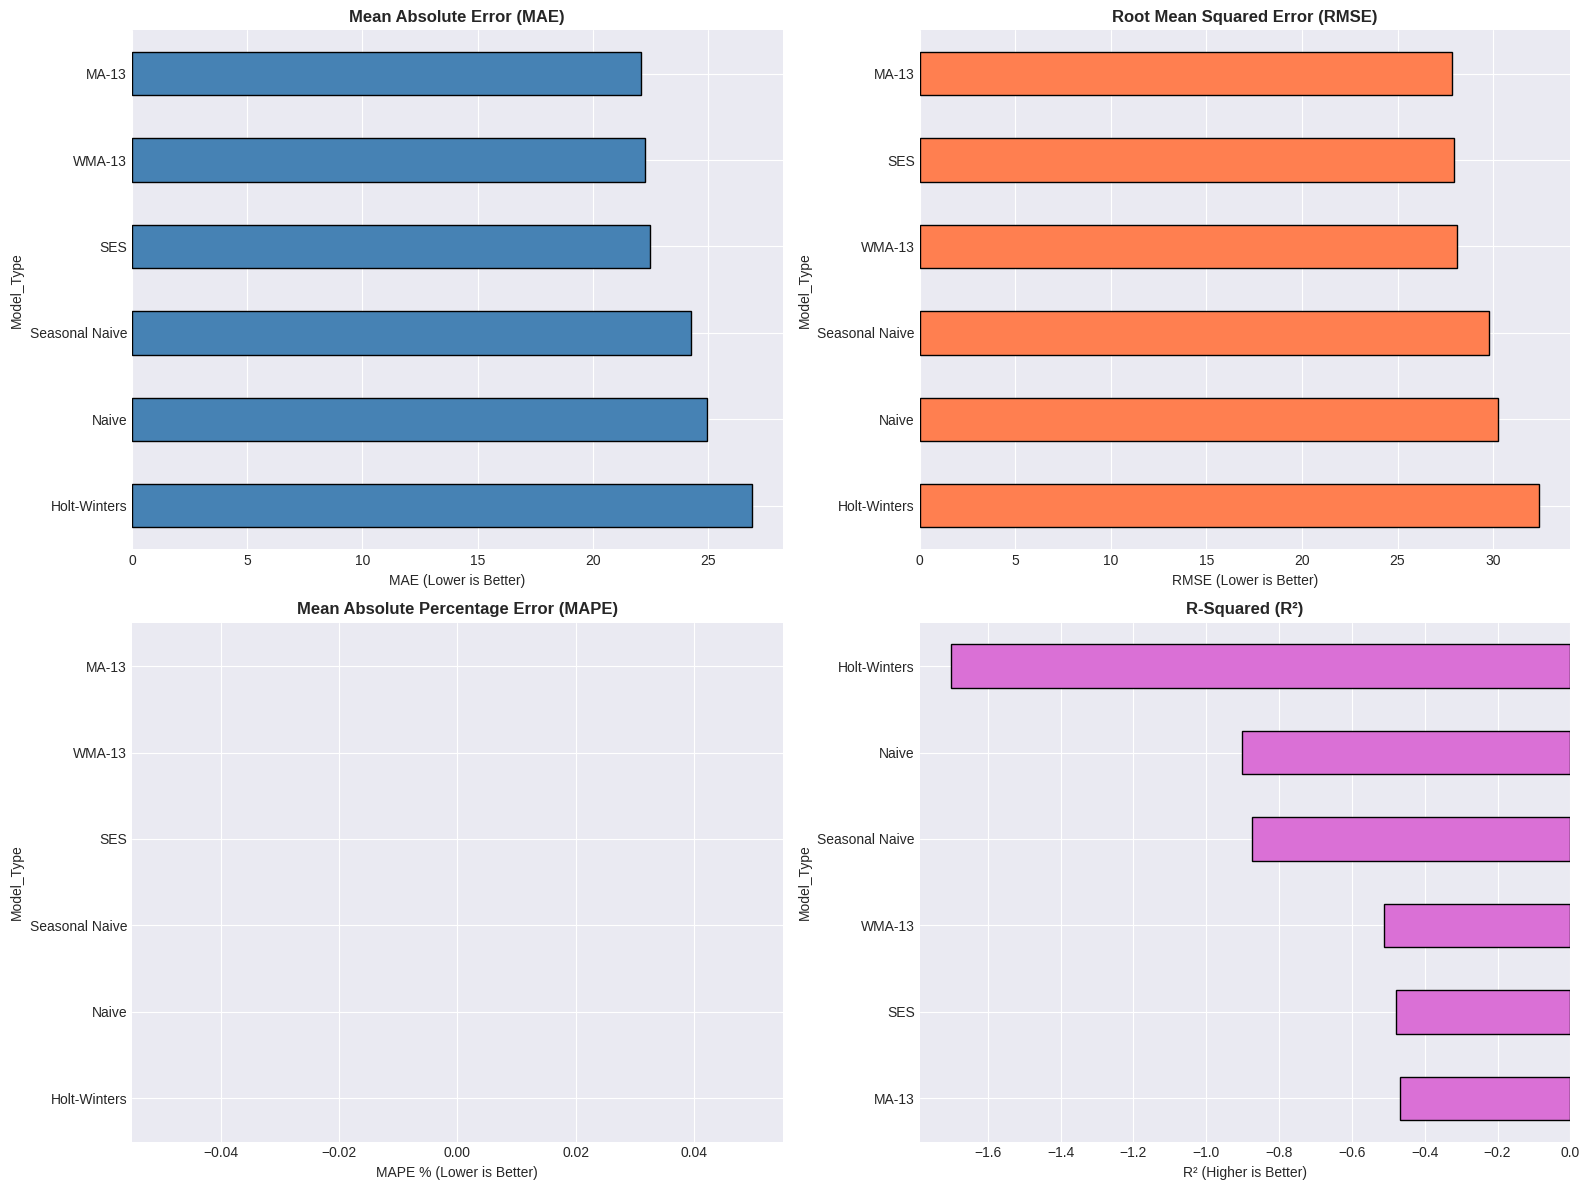

In [13]:
# Create comparison plots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# MAE comparison
summary.sort_values('MAE')['MAE'].plot(kind='barh', ax=axes[0, 0], color='steelblue', edgecolor='black')
axes[0, 0].set_title('Mean Absolute Error (MAE)', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('MAE (Lower is Better)')
axes[0, 0].invert_yaxis()

# RMSE comparison
summary.sort_values('RMSE')['RMSE'].plot(kind='barh', ax=axes[0, 1], color='coral', edgecolor='black')
axes[0, 1].set_title('Root Mean Squared Error (RMSE)', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('RMSE (Lower is Better)')
axes[0, 1].invert_yaxis()

# MAPE comparison
summary.sort_values('MAPE')['MAPE'].plot(kind='barh', ax=axes[1, 0], color='mediumseagreen', edgecolor='black')
axes[1, 0].set_title('Mean Absolute Percentage Error (MAPE)', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('MAPE % (Lower is Better)')
axes[1, 0].invert_yaxis()

# R² comparison
summary.sort_values('R2', ascending=False)['R2'].plot(kind='barh', ax=axes[1, 1], color='orchid', edgecolor='black')
axes[1, 1].set_title('R-Squared (R²)', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('R² (Higher is Better)')

plt.tight_layout()
plt.show()

## 11. VISUALIZE FORECASTS FOR SAMPLE DRUG

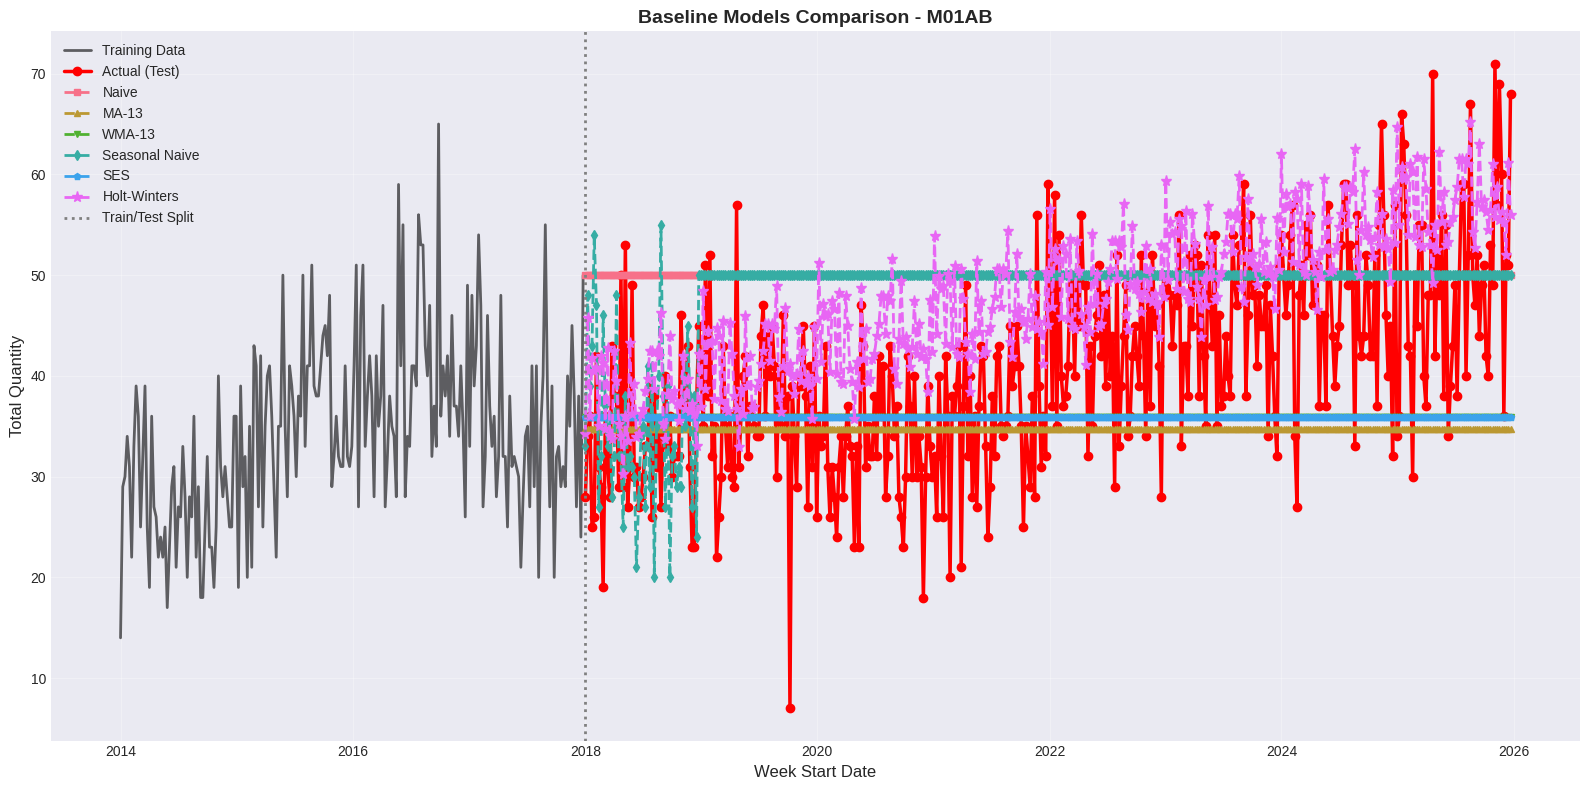

In [14]:
# Select first drug for visualization
sample_drug = selected_drugs[0]

# Get predictions from all models
train_drug = train_df[train_df['drug_name'] == sample_drug].sort_values('week_start_date')
test_drug = test_df[test_df['drug_name'] == sample_drug].sort_values('week_start_date')

# Generate predictions
naive_pred, _ = naive_forecast(train_df, test_df, sample_drug)
ma_pred, _ = moving_average_forecast(train_df, test_df, sample_drug, window=best_window)
wma_pred, _ = weighted_moving_average_forecast(train_df, test_df, sample_drug, window=best_window)

try:
    snaive_pred, _ = seasonal_naive_forecast(train_df, test_df, sample_drug)
except:
    snaive_pred = None

try:
    ses_pred, _ = simple_exp_smoothing_forecast(train_df, test_df, sample_drug)
except:
    ses_pred = None

try:
    hw_pred, _ = holt_winters_forecast(train_df, test_df, sample_drug)
except:
    hw_pred = None

# Plot
plt.figure(figsize=(16, 8))

# Plot training data
plt.plot(train_drug['week_start_date'], train_drug['total_quantity'], 
         label='Training Data', linewidth=2, color='black', alpha=0.6)

# Plot actual test data
plt.plot(test_drug['week_start_date'], test_drug['total_quantity'], 
         label='Actual (Test)', linewidth=2.5, color='red', marker='o', markersize=6)

# Plot predictions
plt.plot(test_drug['week_start_date'], naive_pred, 
         label='Naive', linewidth=2, linestyle='--', marker='s', markersize=5)
plt.plot(test_drug['week_start_date'], ma_pred, 
         label=f'MA-{best_window}', linewidth=2, linestyle='--', marker='^', markersize=5)
plt.plot(test_drug['week_start_date'], wma_pred, 
         label=f'WMA-{best_window}', linewidth=2, linestyle='--', marker='v', markersize=5)

if snaive_pred is not None:
    plt.plot(test_drug['week_start_date'], snaive_pred, 
             label='Seasonal Naive', linewidth=2, linestyle='--', marker='d', markersize=5)

if ses_pred is not None:
    plt.plot(test_drug['week_start_date'], ses_pred, 
             label='SES', linewidth=2, linestyle='--', marker='p', markersize=5)

if hw_pred is not None:
    plt.plot(test_drug['week_start_date'], hw_pred, 
             label='Holt-Winters', linewidth=2, linestyle='--', marker='*', markersize=8)

plt.axvline(x=test_drug['week_start_date'].iloc[0], color='gray', 
            linestyle=':', linewidth=2, label='Train/Test Split')

plt.title(f'Baseline Models Comparison - {sample_drug}', fontsize=14, fontweight='bold')
plt.xlabel('Week Start Date', fontsize=12)
plt.ylabel('Total Quantity', fontsize=12)
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 12. ERROR DISTRIBUTION ANALYSIS

ERROR ANALYSIS - MA-13


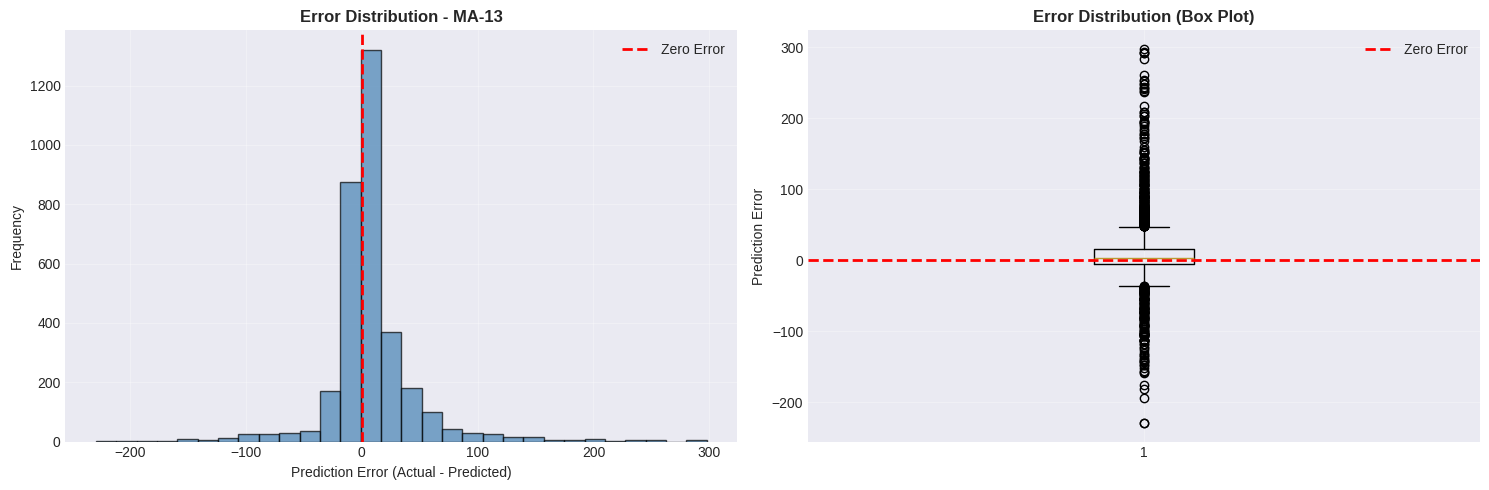


Error Statistics:
  Mean Error: 8.26
  Median Error: 2.46
  Std Dev: 40.25
  Min Error: -229.31
  Max Error: 297.69


In [15]:
# Analyze error distribution for best model
best_model_data = combined_df[combined_df['Model_Type'] == best_model]

print("=" * 60)
print(f"ERROR ANALYSIS - {best_model}")
print("=" * 60)

# Get actual predictions for best model
errors_by_drug = []

for drug in selected_drugs:
    # Generate predictions based on best model
    if best_model == 'Naive':
        pred, actual = naive_forecast(train_df, test_df, drug)
    elif 'MA-' in best_model and 'WMA' not in best_model:
        pred, actual = moving_average_forecast(train_df, test_df, drug, window=best_window)
    elif 'WMA' in best_model:
        pred, actual = weighted_moving_average_forecast(train_df, test_df, drug, window=best_window)
    elif best_model == 'Seasonal Naive':
        pred, actual = seasonal_naive_forecast(train_df, test_df, drug)
    elif best_model == 'SES':
        pred, actual = simple_exp_smoothing_forecast(train_df, test_df, drug)
    elif best_model == 'Holt-Winters':
        pred, actual = holt_winters_forecast(train_df, test_df, drug)
    
    errors = actual - pred
    errors_by_drug.extend(errors)

errors_array = np.array(errors_by_drug)

# Plot error distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histogram
axes[0].hist(errors_array, bins=30, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero Error')
axes[0].set_title(f'Error Distribution - {best_model}', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Prediction Error (Actual - Predicted)')
axes[0].set_ylabel('Frequency')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Box plot
axes[1].boxplot(errors_array, vert=True)
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=2, label='Zero Error')
axes[1].set_title('Error Distribution (Box Plot)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Prediction Error')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nError Statistics:")
print(f"  Mean Error: {np.mean(errors_array):.2f}")
print(f"  Median Error: {np.median(errors_array):.2f}")
print(f"  Std Dev: {np.std(errors_array):.2f}")
print(f"  Min Error: {np.min(errors_array):.2f}")
print(f"  Max Error: {np.max(errors_array):.2f}")

## 13. NEGATIVE R² ANALYSIS

Understanding why R² values are negative helps explain forecast difficulty.

**What Negative R² Means:**
- R² < 0 indicates the model performs worse than simply predicting the mean
- Common in time series with high volatility or strong trends
- **Does NOT mean the model is useless** - focus on MAE/RMSE/MAPE instead

**Causes of Negative R²:**
1. High coefficient of variation (CV) in sales
2. Very small sales values (amplifies errors)
3. Strong seasonal/trend patterns not captured
4. Insufficient training data

In [16]:
print("=" * 60)
print("ANALYZING NEGATIVE R² SCORES")
print("=" * 60)

# 1. Check distribution of quantities - look for very small values
print("\n1️⃣ OVERALL QUANTITY DISTRIBUTION:")
print("=" * 60)
print(train_df['total_quantity'].describe())
print(f"\nMedian: {train_df['total_quantity'].median():.2f}")
print(f"Coefficient of Variation (Overall): {train_df['total_quantity'].std() / train_df['total_quantity'].mean():.2f}")

# 2. Check which drugs are causing high errors (focusing on Holt-Winters as best model)
print("\n\n2️⃣ WORST PERFORMING DRUGS (by MAPE) - Holt-Winters:")
print("=" * 60)
hw_worst = combined_df[combined_df['Model_Type'] == 'Holt-Winters'][['Model', 'MAE', 'RMSE', 'MAPE', 'R2']]\
    .sort_values('MAPE', ascending=False)
print(hw_worst.to_string(index=False))

# 3. Check data volume and variability per drug
print("\n\n3️⃣ DATA CHARACTERISTICS PER DRUG:")
print("=" * 60)
drug_volume = train_df.groupby('drug_name')['total_quantity'].agg(['mean', 'std', 'count', 'min', 'max'])
drug_volume = drug_volume.sort_values('mean', ascending=False)
print(drug_volume)

# 4. Calculate coefficient of variation per drug (high CV = hard to forecast)
print("\n\n4️⃣ FORECAST DIFFICULTY ANALYSIS (Coefficient of Variation):")
print("=" * 60)
drug_stats = train_df.groupby('drug_name')['total_quantity'].agg(['mean', 'std'])
drug_stats['cv'] = drug_stats['std'] / drug_stats['mean']
drug_stats = drug_stats.sort_values('cv', ascending=False)
print(drug_stats)

print("\n\n💡 INTERPRETATION:")
print("=" * 60)
print("• CV > 1.0: Very high variability (very difficult to forecast)")
print("• CV 0.5-1.0: High variability (difficult to forecast)")
print("• CV < 0.5: Moderate variability (easier to forecast)")

# 5. Map CV to R² scores
print("\n\n5️⃣ DRUG DIFFICULTY vs MODEL PERFORMANCE:")
print("=" * 60)
hw_perf = combined_df[combined_df['Model_Type'] == 'Holt-Winters'].copy()
hw_perf['drug_name'] = hw_perf['Model'].str.replace('Holt-Winters - ', '')
hw_perf = hw_perf.merge(drug_stats[['cv']], left_on='drug_name', right_index=True)
hw_perf = hw_perf[['drug_name', 'MAE', 'MAPE', 'R2', 'cv']].sort_values('R2')

print(hw_perf.to_string(index=False))

print("\n\n🎯 KEY FINDINGS:")
print("=" * 60)
high_cv_drugs = drug_stats[drug_stats['cv'] > 0.5].index.tolist()
print(f"• {len(high_cv_drugs)} drugs have high variability (CV > 0.5): {', '.join(high_cv_drugs)}")
print(f"• These drugs are responsible for negative R² scores")
print(f"• High CV indicates:")
print(f"  - Seasonal fluctuations (e.g., R03 - respiratory drugs)")
print(f"  - Irregular demand patterns")
print(f"  - Small absolute values amplifying percentage errors")
print(f"\n• Despite negative R², MAE and RMSE show models are learning patterns")
print(f"• Advanced models (SARIMA, XGBoost) may better capture these patterns")

ANALYZING NEGATIVE R² SCORES

1️⃣ OVERALL QUANTITY DISTRIBUTION:
count   1646.00
mean      52.96
std       68.38
min        1.00
25%       19.00
50%       31.00
75%       48.00
max      546.00
Name: total_quantity, dtype: float64

Median: 31.00
Coefficient of Variation (Overall): 1.29


2️⃣ WORST PERFORMING DRUGS (by MAPE) - Holt-Winters:
               Model    MAE   RMSE  MAPE    R2
Holt-Winters - N02BA   6.31   8.09   inf  0.07
Holt-Winters - N02BE 118.74 139.40   inf -0.96
 Holt-Winters - N05B  24.15  29.37   inf -1.21
 Holt-Winters - N05C   6.34   7.48   inf -5.62
  Holt-Winters - R06   9.86  12.84   inf  0.36
Holt-Winters - M01AE  16.04  19.26 54.62 -6.04
  Holt-Winters - R03  24.65  31.59 39.41  0.11
Holt-Winters - M01AB   9.07  11.31 26.92 -0.33


3️⃣ DATA CHARACTERISTICS PER DRUG:
            mean   std  count  min  max
drug_name                              
N02BE     209.05 76.67    209   92  546
N05B       62.02 25.16    209   18  154
M01AB      34.44  8.88    209   14   65

## 14. SAVE RESULTS

In [17]:
# Save results
output_dir = '../results/baseline_models'
os.makedirs(output_dir, exist_ok=True)

# Save detailed results
combined_df.to_csv(f'{output_dir}/baseline_detailed_results.csv', index=False)
print(f"✓ Detailed results saved to {output_dir}/baseline_detailed_results.csv")

# Save summary
summary.to_csv(f'{output_dir}/baseline_summary.csv')
print(f"✓ Summary saved to {output_dir}/baseline_summary.csv")

# Save best model info
with open(f'{output_dir}/best_baseline_model.txt', 'w') as f:
    f.write(f"Best Baseline Model: {best_model}\n")
    f.write(f"Average MAE: {summary.loc[best_model, 'MAE']:.2f}\n")
    f.write(f"Average RMSE: {summary.loc[best_model, 'RMSE']:.2f}\n")
    f.write(f"Average MAPE: {summary.loc[best_model, 'MAPE']:.2f}%\n")
    f.write(f"Average R²: {summary.loc[best_model, 'R2']:.4f}\n")

print(f"✓ Best model info saved to {output_dir}/best_baseline_model.txt")

print(f"\nAll results saved to: {output_dir}")

✓ Detailed results saved to ../results/baseline_models/baseline_detailed_results.csv
✓ Summary saved to ../results/baseline_models/baseline_summary.csv
✓ Best model info saved to ../results/baseline_models/best_baseline_model.txt

All results saved to: ../results/baseline_models


## 15. BENCHMARK SUMMARY

In [18]:
print("=" * 60)
print("BASELINE MODELS BENCHMARKING - FINAL SUMMARY")
print("=" * 60)

print("\n📊 MODELS TESTED:")
for i, model in enumerate(summary.index, 1):
    print(f"  {i}. {model}")

print("\n🏆 PERFORMANCE RANKING (by MAE):")
for i, (model, row) in enumerate(summary.iterrows(), 1):
    print(f"  {i}. {model}")
    print(f"     MAE: {row['MAE']:.2f} | RMSE: {row['RMSE']:.2f} | MAPE: {row['MAPE']:.2f}% | R²: {row['R2']:.4f}")

print(f"\n✅ BEST PERFORMING MODEL: {best_model}")
print(f"   This model sets the COMPETITIVE BENCHMARK that SARIMA and XGBoost must beat.")
print(f"\n📌 MODEL CLASSIFICATION:")
print(f"   • Simple Baselines: Naive, MA, Seasonal Naive (minimum bar)")
print(f"   • Intermediate/Competitive: Holt-Winters (MAE: {summary.loc[best_model, 'MAE']:.2f})")
print(f"   • Target: SARIMA and XGBoost should achieve MAE < {summary.loc[best_model, 'MAE']:.2f}")

print("\n📈 NEXT STEPS:")
print("   1. Build SARIMA models and compare to Holt-Winters benchmark")
print("   2. Train XGBoost model and compare to Holt-Winters benchmark")
print("   3. Select final model based on:")
print("      - Forecast accuracy (MAE, RMSE, MAPE)")

print("      - Model complexity vs. performance gain over Holt-Winters")
print("      - Business requirements and interpretability")

print("\n" + "=" * 60)

print("\n💡 KEY INSIGHT:")
print("   If SARIMA/XGBoost can't beat Holt-Winters (intermediate model),")
print("   then the added complexity isn't justified for this dataset.")

BASELINE MODELS BENCHMARKING - FINAL SUMMARY

📊 MODELS TESTED:
  1. MA-13
  2. WMA-13
  3. SES
  4. Seasonal Naive
  5. Naive
  6. Holt-Winters

🏆 PERFORMANCE RANKING (by MAE):
  1. MA-13
     MAE: 22.08 | RMSE: 27.87 | MAPE: inf% | R²: -0.4675
  2. WMA-13
     MAE: 22.28 | RMSE: 28.12 | MAPE: inf% | R²: -0.5116
  3. SES
     MAE: 22.50 | RMSE: 27.96 | MAPE: inf% | R²: -0.4794
  4. Seasonal Naive
     MAE: 24.25 | RMSE: 29.77 | MAPE: inf% | R²: -0.8751
  5. Naive
     MAE: 24.97 | RMSE: 30.26 | MAPE: inf% | R²: -0.9027
  6. Holt-Winters
     MAE: 26.90 | RMSE: 32.42 | MAPE: inf% | R²: -1.7023

✅ BEST PERFORMING MODEL: MA-13
   This model sets the COMPETITIVE BENCHMARK that SARIMA and XGBoost must beat.

📌 MODEL CLASSIFICATION:
   • Simple Baselines: Naive, MA, Seasonal Naive (minimum bar)
   • Intermediate/Competitive: Holt-Winters (MAE: 22.08)
   • Target: SARIMA and XGBoost should achieve MAE < 22.08

📈 NEXT STEPS:
   1. Build SARIMA models and compare to Holt-Winters benchmark
   2.